In [1]:
import pandas as pd
import numpy as np

In [2]:
clientes = pd.read_csv("../data/raw/clientes.csv")

productos = pd.read_csv("../data/raw/productos.csv")

transacciones = pd.read_csv("../data/raw/transacciones.csv")

In [3]:
conversaciones = pd.read_csv(
    "../data/raw/conversaciones.csv",
    encoding="latin1"
)

In [4]:
# Limpiezas

conversaciones["input"] = (
    conversaciones["input"]
    .str.replace(
        "Hey Banco",
        "NovaBank",
        regex=False
    )
)

conversaciones["output"] = (
    conversaciones["output"]
    .str.replace(
        "Hey Banco",
        "NovaBank",
        regex=False
    )
)

# Cambiar membresía

conversaciones["input"] = (
    conversaciones["input"]
    .str.replace(
        "Hey Pro",
        "Nova+",
        regex=False
    )
)

conversaciones["output"] = (
    conversaciones["output"]
    .str.replace(
        "Hey Pro",
        "Nova+",
        regex=False
    )
)



In [5]:
clientes.head()

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,527,1,app_android,10.0,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,714,3,app_android,8.0,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,454,3,app_ios,8.0,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,837,16,app_ios,10.0,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,533,1,app_ios,7.0,False,True,es_MX,True,2,False


In [6]:
conversaciones.head()

,input,output,date,conv_id,user_id,channel_source
0,"Me enterÃ© de una promo ""Supercashback Pagos G...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crÃ©dito Hey Negocios es diferen...,Claro! La Tarjeta de CrÃ©dito Hey Negocios es ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",Â¡De nada! Me alegra haber podido ayudarte. Si...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
3,Hola,Â¡Hola! Â¿CÃ³mo estÃ¡s? Estoy aquÃ­ para ayuda...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1
4,VerificaciÃ³n de cuenta,Claro que puedo ayudarte con eso. Para validar...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1


In [7]:
def fix_encoding(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

In [8]:
conversaciones["input"] = conversaciones["input"].apply(fix_encoding)

conversaciones["output"] = conversaciones["output"].apply(fix_encoding)

In [9]:
conversaciones.head()

,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",¡De nada! Me alegra haber podido ayudarte. Si ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
3,Hola,¡Hola! ¿Cómo estás? Estoy aquí para ayudarte c...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1
4,Verificación de cuenta,Claro que puedo ayudarte con eso. Para validar...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1


In [10]:
## VER TAMAÑOS

In [11]:
print(clientes.shape)
print(productos.shape)
print(transacciones.shape)
print(conversaciones.shape)

(15025, 22)
(38909, 13)
(802213, 22)
(49999, 6)


In [12]:
#Tipos de datos
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  15025 non-null  str    
 1   edad                     15025 non-null  int64  
 2   sexo                     15025 non-null  str    
 3   estado                   14593 non-null  str    
 4   ciudad                   14593 non-null  str    
 5   nivel_educativo          15025 non-null  str    
 6   ocupacion                15025 non-null  str    
 7   ingreso_mensual_mxn      15025 non-null  int64  
 8   antiguedad_dias          15025 non-null  int64  
 9   es_hey_pro               15025 non-null  bool   
 10  nomina_domiciliada       15025 non-null  bool   
 11  canal_apertura           15025 non-null  str    
 12  score_buro               15025 non-null  int64  
 13  dias_desde_ultimo_login  15025 non-null  int64  
 14  preferencia_canal        15025 no

In [13]:
transacciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 802213 entries, 0 to 802212
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaccion_id       802213 non-null  str    
 1   user_id              802213 non-null  str    
 2   producto_id          802213 non-null  str    
 3   fecha_hora           802213 non-null  str    
 4   tipo_operacion       802213 non-null  str    
 5   canal                802213 non-null  str    
 6   monto                802213 non-null  float64
 7   comercio_nombre      431762 non-null  str    
 8   categoria_mcc        802213 non-null  str    
 9   ciudad_transaccion   782949 non-null  str    
 10  estatus              802213 non-null  str    
 11  motivo_no_procesada  26604 non-null   str    
 12  intento_numero       802213 non-null  int64  
 13  meses_diferidos      17310 non-null   float64
 14  cashback_generado    180606 non-null  float64
 15  descripcion_libre    740472 

In [14]:
## NULOS 

In [15]:
clientes.isnull().sum()

user_id                      0
edad                         0
sexo                         0
estado                     432
ciudad                     432
nivel_educativo              0
ocupacion                    0
ingreso_mensual_mxn          0
antiguedad_dias              0
es_hey_pro                   0
nomina_domiciliada           0
canal_apertura               0
score_buro                   0
dias_desde_ultimo_login      0
preferencia_canal            0
satisfaccion_1_10          751
recibe_remesas               0
usa_hey_shop                 0
idioma_preferido             0
tiene_seguro                 0
num_productos_activos        0
patron_uso_atipico           0
dtype: int64

In [16]:
productos.isnull().sum()

producto_id                    0
user_id                        0
tipo_producto                  0
fecha_apertura                 0
estatus                        0
limite_credito             24592
saldo_actual                3750
utilizacion_pct            24592
tasa_interes_anual         20118
plazo_meses                34359
monto_mensualidad          34359
fecha_ultimo_movimiento        0
es_dato_sintetico              0
dtype: int64

In [17]:
transacciones.isnull().sum()

transaccion_id              0
user_id                     0
producto_id                 0
fecha_hora                  0
tipo_operacion              0
canal                       0
monto                       0
comercio_nombre        370451
categoria_mcc               0
ciudad_transaccion      19264
estatus                     0
motivo_no_procesada    775609
intento_numero              0
meses_diferidos        784903
cashback_generado      621607
descripcion_libre       61741
hora_del_dia                0
dia_semana                  0
es_internacional            0
dispositivo            202013
patron_uso_atipico          0
es_dato_sintetico           0
dtype: int64

In [18]:
# DUPLICADOS

In [19]:
clientes.duplicated().sum()

np.int64(0)

In [20]:
transacciones.duplicated().sum()

np.int64(0)

In [21]:
## CORRECCIONES

In [22]:
transacciones["fecha_hora"] = pd.to_datetime(
    transacciones["fecha_hora"],
    dayfirst=True
)

In [23]:
transacciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 802213 entries, 0 to 802212
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transaccion_id       802213 non-null  str           
 1   user_id              802213 non-null  str           
 2   producto_id          802213 non-null  str           
 3   fecha_hora           802213 non-null  datetime64[us]
 4   tipo_operacion       802213 non-null  str           
 5   canal                802213 non-null  str           
 6   monto                802213 non-null  float64       
 7   comercio_nombre      431762 non-null  str           
 8   categoria_mcc        802213 non-null  str           
 9   ciudad_transaccion   782949 non-null  str           
 10  estatus              802213 non-null  str           
 11  motivo_no_procesada  26604 non-null   str           
 12  intento_numero       802213 non-null  int64         
 13  meses_diferidos      1731

# SIGUIENTES PASOS EXPLORAR DATOS

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

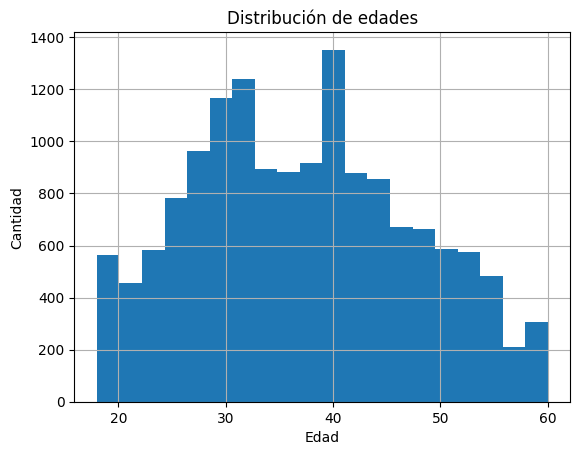

In [25]:
# DISTRIBUCION EDADES
clientes["edad"].hist(bins=20)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()

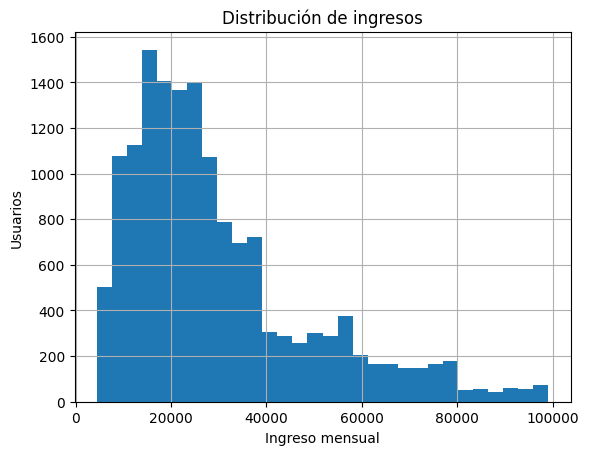

In [26]:
# INGRESOS
clientes["ingreso_mensual_mxn"].hist(bins=30)

plt.title("Distribución de ingresos")
plt.xlabel("Ingreso mensual")
plt.ylabel("Usuarios")
plt.show()

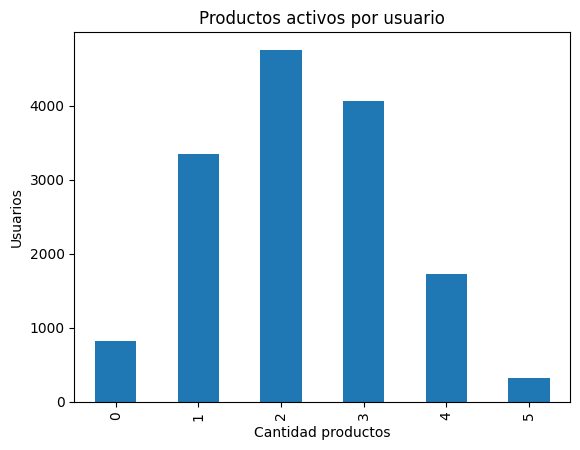

In [27]:
# PRODUCTOS ACTIVOS
clientes["num_productos_activos"].value_counts().sort_index().plot(kind="bar")

plt.title("Productos activos por usuario")
plt.xlabel("Cantidad productos")
plt.ylabel("Usuarios")
plt.show()

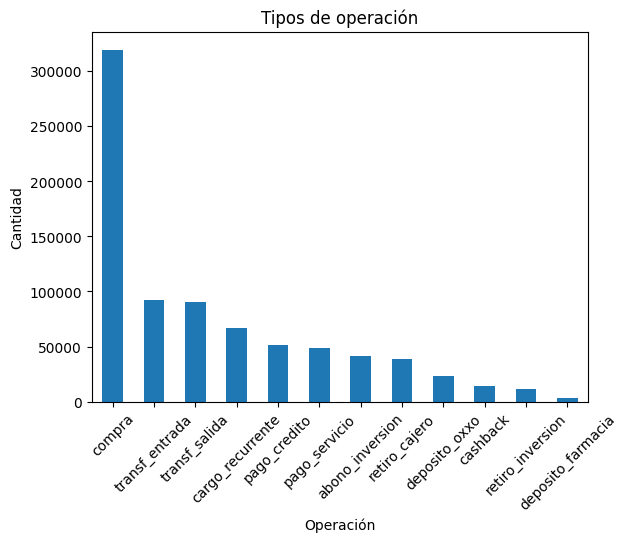

In [28]:
# OPERACIONES MAS COMUNES
transacciones["tipo_operacion"].value_counts().plot(kind="bar")

plt.title("Tipos de operación")
plt.xlabel("Operación")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

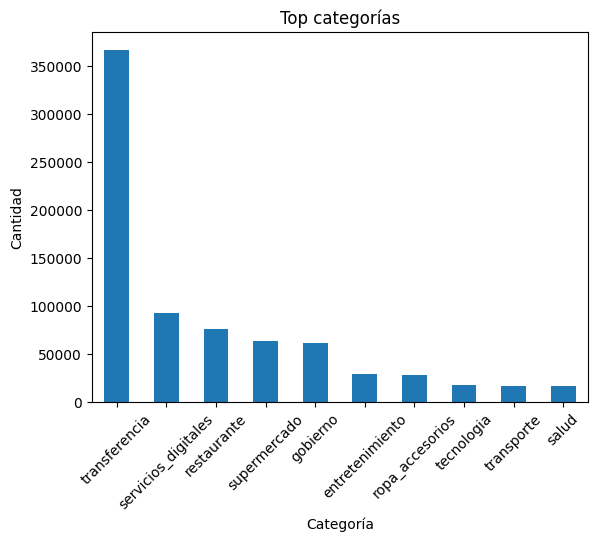

In [29]:
# CATEGORIAS MAS USADAS
transacciones["categoria_mcc"].value_counts().head(10).plot(kind="bar")

plt.title("Top categorías")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

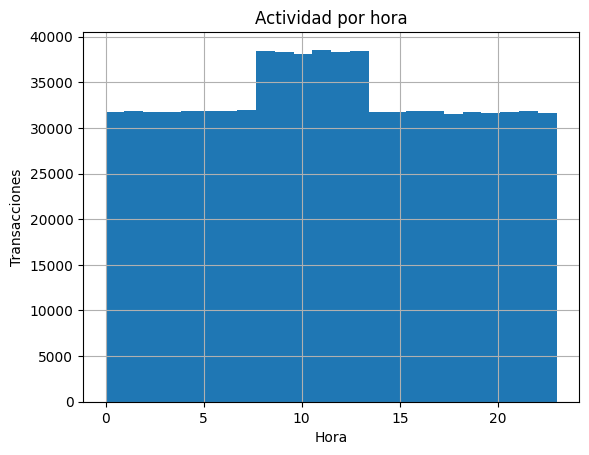

In [30]:
# HORAS MAS ACTIVAS
transacciones["hora_del_dia"].hist(bins=24)

plt.title("Actividad por hora")
plt.xlabel("Hora")
plt.ylabel("Transacciones")
plt.show()

In [31]:
## INSIGTHS

In [32]:
# GASTO PROM. POR USUARIO
gasto_usuario = transacciones.groupby("user_id")["monto"].sum()

gasto_usuario.describe()

count    1.502500e+04
mean     3.261414e+05
std      2.368850e+05
min      2.405350e+03
25%      1.543477e+05
50%      2.436138e+05
75%      4.972572e+05
max      1.508073e+06
Name: monto, dtype: float64

In [33]:
# TOP CATEGORIAS DE GASTOS
top_categorias = transacciones.groupby("categoria_mcc")["monto"].sum()

top_categorias.sort_values(ascending=False)

categoria_mcc
transferencia          4.243785e+09
gobierno               1.254913e+08
supermercado           1.166176e+08
restaurante            8.289795e+07
servicios_digitales    5.380092e+07
hogar                  4.991304e+07
transporte             4.884508e+07
tecnologia             4.021531e+07
viajes                 3.989870e+07
ropa_accesorios        2.885221e+07
entretenimiento        2.544835e+07
salud                  2.381128e+07
educacion              1.782851e+07
retiro_cajero          2.869036e+06
Name: monto, dtype: float64

In [34]:
## USUARIOS PRO VS NORMALES

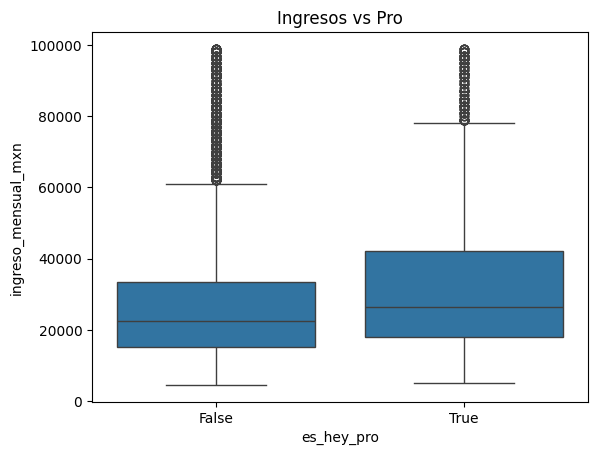

In [35]:
clientes["es_hey_pro"].value_counts()
sns.boxplot(
    x=clientes["es_hey_pro"],
    y=clientes["ingreso_mensual_mxn"]
)

plt.title("Ingresos vs Pro")
plt.show()

In [36]:
# USO ATIPICO
clientes["patron_uso_atipico"].value_counts()
transacciones["patron_uso_atipico"].value_counts()

patron_uso_atipico
False    760728
True      41485
Name: count, dtype: int64

In [37]:
# TRANSACCIONES INTERNACIONOALES
transacciones["es_internacional"].value_counts()

es_internacional
False    762210
True      40003
Name: count, dtype: int64

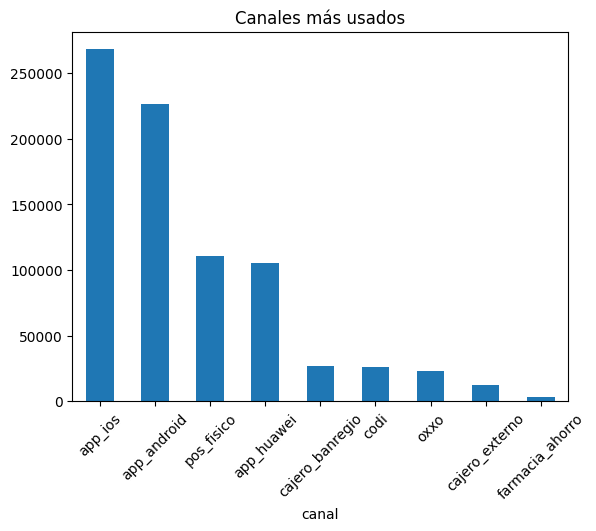

In [38]:
# CANALES MAS USADOS
transacciones["canal"].value_counts().plot(kind="bar")

plt.title("Canales más usados")
plt.xticks(rotation=45)
plt.show()

In [39]:
# Guardado de datasets procesados

In [40]:
clientes.to_csv(
    "../data/processed/clientes_clean.csv",
    index=False
)

productos.to_csv(
    "../data/processed/productos_clean.csv",
    index=False
)

transacciones.to_csv(
    "../data/processed/transacciones_clean.csv",
    index=False
)

conversaciones.to_csv(
    "../data/processed/conversaciones_clean.csv",
    index=False
)

In [41]:
print(clientes.columns)

Index(['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo',
       'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico'],
      dtype='str')


In [42]:
print(clientes.head())

     user_id  edad sexo            estado                ciudad  \
0  USR-00001    21    M  Ciudad de México  CDMX - Benito Juárez   
1  USR-00002    18    M           Jalisco       Puerto Vallarta   
2  USR-00003    23    H         Chihuahua            Cuauhtémoc   
3  USR-00004    32   SE        Nuevo León             Guadalupe   
4  USR-00005    26    M  Ciudad de México     CDMX - Cuauhtémoc   

  nivel_educativo   ocupacion  ingreso_mensual_mxn  antiguedad_dias  \
0    Preparatoria    Empleado                24500             1554   
1    Preparatoria  Estudiante                19000             1410   
2    Licenciatura  Estudiante                14000             1174   
3        Posgrado    Empleado                61000             1168   
4    Preparatoria  Empresario                27000              816   

   es_hey_pro  ...  score_buro dias_desde_ultimo_login  preferencia_canal  \
0        True  ...         527                       1        app_android   
1        True  .

In [43]:
print(productos.columns)

Index(['producto_id', 'user_id', 'tipo_producto', 'fecha_apertura', 'estatus',
       'limite_credito', 'saldo_actual', 'utilizacion_pct',
       'tasa_interes_anual', 'plazo_meses', 'monto_mensualidad',
       'fecha_ultimo_movimiento', 'es_dato_sintetico'],
      dtype='str')
